# Lab Assignment 4: NLP Preprocessing and Text Classification

**Name:** Om Waman Panchal

**PRN:** 202301040176

**Batch:** D3

**Branch:** Computer Engineering

**Subject:** Deep Learning (MDM)

**Github:** [https://github.com/om9494/AIML-Assignments.git](https://github.com/om9494/AIML-Assignments.git)


**Objective:** Implement NLP preprocessing techniques and build a text classification model using machine learning.

**Learning Outcomes:**
- Apply NLP preprocessing (tokenization, stopword removal, stemming, lemmatization)
- Implement text vectorization (TF-IDF, CountVectorizer)
- Build a machine learning classification model
- Evaluate model performance using metrics

---

## 1. Import Required Libraries

Import essential libraries including NumPy, Pandas, Scikit-learn, NLTK, and Matplotlib for NLP and machine learning tasks.

In [ ]:
# Install required packages
!pip install nltk scikit-learn pandas numpy matplotlib seaborn --quiet

print("✅ All packages installed successfully!")

✅ All packages installed successfully!


In [ ]:
# Import libraries for NLP and ML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# Download NLTK datasets
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print("✅ NLTK data downloaded!")

✅ NLTK data downloaded!


## 2. Load and Explore Dataset

Load a text classification dataset (Movie Reviews Dataset), display basic information such as shape, data types, and sample data. Check for missing values and class distribution.

In [ ]:
# Create a sample dataset of movie reviews (different from reference notebook)
# Using product reviews dataset for sentiment classification

data = {
    'review': [
        'This product is amazing and exceeded my expectations. Highly recommended!',
        'The quality is poor and it broke after one week. Very disappointed.',
        'Excellent product with great customer service. Very satisfied.',
        'Not worth the money. Bad quality and slow delivery.',
        'Outstanding experience! Fast shipping and perfect product.',
        'Terrible product. Do not buy this at all.',
        'Best purchase ever. Great value for money.',
        'Disappointed with the quality. Expected better.',
        'Perfect! Everything is as described. Happy customer.',
        'Worst product I have ever bought. Complete waste of money.',
        'Fantastic quality and fast delivery. Highly recommend!',
        'Poor quality and bad customer support. Returning it.',
        'Exceptional product with amazing features. Love it!',
        'Horrible experience. Product arrived damaged and defective.',
        'Wonderful! Exceeded all my expectations. Great purchase!',
        'Below average quality. Not satisfied with purchase.',
        'Superb product and excellent service. Five stars!',
        'Cheap quality. Regret buying this product.',
        'Outstanding value and high quality. Very happy!',
        'Awful product. Broke on the first day of use.'
    ],
    'sentiment': [
        'positive', 'negative', 'positive', 'negative', 'positive',
        'negative', 'positive', 'negative', 'positive', 'negative',
        'positive', 'negative', 'positive', 'negative', 'positive',
        'negative', 'positive', 'negative', 'positive', 'negative'
    ]
}

df = pd.DataFrame(data)

print("📊 Dataset Shape:", df.shape)
print("\n📋 First few rows:")
print(df.head(10))
print("\n📈 Dataset Info:")
print(df.info())
print("\n✅ Missing Values:")
print(df.isnull().sum())
print("\n🏷️ Class Distribution:")
print(df['sentiment'].value_counts())
print(f"\nDataset has {df.shape[0]} samples")

📊 Dataset Shape: (20, 2)

📋 First few rows:
                                              review sentiment
0  This product is amazing and exceeded my expect...  positive
1  The quality is poor and it broke after one wee...  negative
2  Excellent product with great customer service....  positive
3  Not worth the money. Bad quality and slow deli...  negative
4  Outstanding experience! Fast shipping and perf...  positive
5          Terrible product. Do not buy this at all.  negative
6         Best purchase ever. Great value for money.  positive
7    Disappointed with the quality. Expected better.  negative
8  Perfect! Everything is as described. Happy cus...  positive
9  Worst product I have ever bought. Complete was...  negative

📈 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     20 non-null     object
 1   sentiment  20 non-null

## 3. Text Preprocessing: Tokenization and Stopword Removal

Tokenize text into words and remove common stopwords using NLTK. Create a function to handle these preprocessing steps.

In [ ]:
# Initialize stopwords
stop_words = set(stopwords.words('english'))

print(f"📊 Total English stopwords: {len(stop_words)}")
print(f"\n📝 Sample stopwords: {list(stop_words)[:20]}")

📊 Total English stopwords: 198

📝 Sample stopwords: ["mightn't", "she's", 'do', 'whom', "you'd", 'their', 'theirs', 'me', 'where', 'then', 'up', 'wasn', 're', 'couldn', 'there', 'more', 'both', 'shouldn', "you'll", "it'd"]


In [ ]:
# Function to tokenize and remove stopwords
def tokenize_and_remove_stopwords(text):
    """
    Tokenize text and remove stopwords

    Parameters:
    text (str): Input text

    Returns:
    list: List of tokens without stopwords
    """
    # Convert to lowercase
    text = text.lower()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and punctuation
    filtered_tokens = [token for token in tokens if token.isalnum() and token not in stop_words]

    return filtered_tokens

# Test on a sample review
sample_review = df['review'].iloc[0]
print(f"📝 Original text:\n{sample_review}")
print(f"\n🔤 Tokens (without stopwords):")
tokens = tokenize_and_remove_stopwords(sample_review)
print(tokens)
print(f"\n📊 Number of tokens: {len(tokens)}")

📝 Original text:
This product is amazing and exceeded my expectations. Highly recommended!

🔤 Tokens (without stopwords):
['product', 'amazing', 'exceeded', 'expectations', 'highly', 'recommended']

📊 Number of tokens: 6


## 4. Text Preprocessing: Stemming and Lemmatization

Apply stemming using PorterStemmer and lemmatization using WordNetLemmatizer. Compare results of both techniques on sample text.

In [ ]:
# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

print("=" * 60)
print("STEMMING vs LEMMATIZATION - Comparison")
print("=" * 60)

# Sample words to demonstrate stemming and lemmatization
sample_words = ['running', 'runs', 'ran', 'walking', 'walks', 'walked',
                 'better', 'best', 'goodness', 'computing', 'computed']

print(f"\n{'Word':<15} {'Stemmed':<15} {'Lemmatized':<15}")
print("-" * 45)

for word in sample_words:
    stemmed = stemmer.stem(word)
    lemmatized = lemmatizer.lemmatize(word)
    print(f"{word:<15} {stemmed:<15} {lemmatized:<15}")

STEMMING vs LEMMATIZATION - Comparison

Word            Stemmed         Lemmatized     
---------------------------------------------
running         run             running        
runs            run             run            
ran             ran             ran            
walking         walk            walking        
walks           walk            walk           
walked          walk            walked         
better          better          better         
best            best            best           
goodness        good            goodness       
computing       comput          computing      
computed        comput          computed       


In [ ]:
# Apply stemming and lemmatization to tokens
def preprocess_text_complete(text):
    """
    Complete preprocessing: tokenization, stopword removal, and stemming
    """
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token.isalnum() and token not in stop_words]
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    return stemmed_tokens

# Test on sample review
sample_review = df['review'].iloc[0]
print(f"📝 Original review:\n{sample_review}")
print(f"\n🔤 After tokenization and stopword removal:")
tokens = tokenize_and_remove_stopwords(sample_review)
print(tokens)
print(f"\n✂️ After stemming:")
stemmed = preprocess_text_complete(sample_review)
print(stemmed)
print(f"\n📊 Vocabulary reduction: {len(tokens)} → {len(stemmed)} unique stems")

📝 Original review:
This product is amazing and exceeded my expectations. Highly recommended!

🔤 After tokenization and stopword removal:
['product', 'amazing', 'exceeded', 'expectations', 'highly', 'recommended']

✂️ After stemming:
['product', 'amaz', 'exceed', 'expect', 'highli', 'recommend']

📊 Vocabulary reduction: 6 → 6 unique stems


## 5. Text Vectorization with TF-IDF

Use TfidfVectorizer from Scikit-learn to convert preprocessed text into numerical feature vectors. Display the shape and sample features.

In [ ]:
# Apply TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(
    max_features=100,  # Limit to top 100 features
    stop_words='english',
    lowercase=True,
    min_df=1,  # Ignore terms appearing in less than 1 document
    max_df=0.8  # Ignore terms appearing in more than 80% of documents
)

# Fit and transform the reviews
X_tfidf = tfidf_vectorizer.fit_transform(df['review'])

print("📊 TF-IDF Vectorization Results:")
print(f"   Shape: {X_tfidf.shape}  (samples × features)")
print(f"   Sparsity: {(1.0 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100:.2f}%")
print(f"\n🏷️ Top 20 features (words):")
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
print(feature_names[:20])

📊 TF-IDF Vectorization Results:
   Shape: (20, 61)  (samples × features)
   Sparsity: 91.56%

🏷️ Top 20 features (words):
['amazing' 'arrived' 'average' 'awful' 'bad' 'best' 'better' 'bought'
 'broke' 'buy' 'buying' 'cheap' 'complete' 'customer' 'damaged' 'day'
 'defective' 'delivery' 'described' 'disappointed']


In [ ]:
# Display TF-IDF scores for the first review
first_review_tfidf = X_tfidf[0].toarray()[0]
top_indices = np.argsort(first_review_tfidf)[::-1][:5]

print(f"📝 Sample Review:\n{df['review'].iloc[0]}")
print(f"\n🎯 Top 5 TF-IDF features for this review:")
print(f"{'Feature':<15} {'TF-IDF Score':<15}")
print("-" * 30)
for idx in top_indices:
    if first_review_tfidf[idx] > 0:
        print(f"{feature_names[idx]:<15} {first_review_tfidf[idx]:<15.4f}")

📝 Sample Review:
This product is amazing and exceeded my expectations. Highly recommended!

🎯 Top 5 TF-IDF features for this review:
Feature         TF-IDF Score   
------------------------------
recommended     0.4805         
highly          0.4223         
amazing         0.4223         
expectations    0.4223         
exceeded        0.4223         


## 6. Text Vectorization with CountVectorizer

Use CountVectorizer to create document-term matrix. Compare the output with TF-IDF vectorization.

In [ ]:
# Apply CountVectorizer (Bag of Words)
count_vectorizer = CountVectorizer(
    max_features=100,
    stop_words='english',
    lowercase=True,
    min_df=1,
    max_df=0.8
)

# Fit and transform the reviews
X_count = count_vectorizer.fit_transform(df['review'])

print("📊 CountVectorizer (Bag of Words) Results:")
print(f"   Shape: {X_count.shape}  (samples × features)")
print(f"   Sparsity: {(1.0 - X_count.nnz / (X_count.shape[0] * X_count.shape[1])) * 100:.2f}%")
print(f"\n📈 Document-Term Matrix (first 5 documents, first 10 terms):")
print(X_count[:5, :10].toarray())

📊 CountVectorizer (Bag of Words) Results:
   Shape: (20, 61)  (samples × features)
   Sparsity: 91.56%

📈 Document-Term Matrix (first 5 documents, first 10 terms):
[[1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0]]


In [ ]:
# Comparison of TF-IDF vs CountVectorizer
print("\n" + "="*60)
print("COMPARISON: TF-IDF vs CountVectorizer")
print("="*60)

print(f"\n1️⃣ TF-IDF:")
print(f"   - Accounts for term frequency and inverse document frequency")
print(f"   - Values are weighted (0.0 to 1.0)")
print(f"   - Better for text classification (reduces common word bias)")
print(f"   - Max value in matrix: {X_tfidf.max():.4f}")

print(f"\n2️⃣ CountVectorizer (Bag of Words):")
print(f"   - Simple word count (raw frequencies)")
print(f"   - Values are integers (counts)")
print(f"   - Faster computation, easier to interpret")
print(f"   - Max value in matrix: {X_count.max()}")

print(f"\n✅ For this assignment, we'll use TF-IDF as it's better for classification.")


COMPARISON: TF-IDF vs CountVectorizer

1️⃣ TF-IDF:
   - Accounts for term frequency and inverse document frequency
   - Values are weighted (0.0 to 1.0)
   - Better for text classification (reduces common word bias)
   - Max value in matrix: 0.6679

2️⃣ CountVectorizer (Bag of Words):
   - Simple word count (raw frequencies)
   - Values are integers (counts)
   - Faster computation, easier to interpret
   - Max value in matrix: 1

✅ For this assignment, we'll use TF-IDF as it's better for classification.


## 7. Build Classification Model

Instantiate machine learning classifiers: Naive Bayes and Logistic Regression.

In [ ]:
# Convert sentiment labels to binary (0 for negative, 1 for positive)
y = (df['sentiment'] == 'positive').astype(int)

print("🏷️ Label Distribution:")
print(f"   Positive (1): {(y == 1).sum()}")
print(f"   Negative (0): {(y == 0).sum()}")

🏷️ Label Distribution:
   Positive (1): 10
   Negative (0): 10


In [ ]:
## 8. Train the Model
# Split data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

print("📊 Train-Test Split:")
print(f"   Training set size: {X_train.shape[0]}")
print(f"   Testing set size: {X_test.shape[0]}")
print(f"   Total features: {X_train.shape[1]}")

📊 Train-Test Split:
   Training set size: 16
   Testing set size: 4
   Total features: 61


In [ ]:
# Initialize and train Multinomial Naive Bayes classifier
print("🚀 Training Multinomial Naive Bayes Classifier...")
naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train, y_train)
print("✅ Naive Bayes model trained!")

# Initialize and train Logistic Regression classifier
print("\n🚀 Training Logistic Regression Classifier...")
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train, y_train)
print("✅ Logistic Regression model trained!")

🚀 Training Multinomial Naive Bayes Classifier...
✅ Naive Bayes model trained!

🚀 Training Logistic Regression Classifier...
✅ Logistic Regression model trained!


## 9. Evaluate Model Performance

Generate predictions on test data. Calculate and display evaluation metrics including accuracy, precision, recall, F1-score, and confusion matrix.

In [ ]:
# Make predictions using both models
y_pred_nb = naive_bayes_model.predict(X_test)
y_pred_lr = logistic_model.predict(X_test)

print("✅ Predictions made on test set!")

✅ Predictions made on test set!


In [ ]:
# Calculate evaluation metrics for Naive Bayes
print("\n" + "="*60)
print("NAIVE BAYES CLASSIFIER - EVALUATION METRICS")
print("="*60)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, zero_division=0)
recall_nb = recall_score(y_test, y_pred_nb, zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, zero_division=0)

print(f"\n📊 Metrics:")
print(f"   Accuracy:  {accuracy_nb:.4f} ({accuracy_nb*100:.2f}%)")
print(f"   Precision: {precision_nb:.4f}")
print(f"   Recall:    {recall_nb:.4f}")
print(f"   F1-Score:  {f1_nb:.4f}")

print(f"\n🔍 Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['Negative', 'Positive']))


NAIVE BAYES CLASSIFIER - EVALUATION METRICS

📊 Metrics:
   Accuracy:  1.0000 (100.00%)
   Precision: 1.0000
   Recall:    1.0000
   F1-Score:  1.0000

🔍 Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         2
    Positive       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [ ]:
# Calculate evaluation metrics for Logistic Regression
print("\n" + "="*60)
print("LOGISTIC REGRESSION CLASSIFIER - EVALUATION METRICS")
print("="*60)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)

print(f"\n📊 Metrics:")
print(f"   Accuracy:  {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"   Precision: {precision_lr:.4f}")
print(f"   Recall:    {recall_lr:.4f}")
print(f"   F1-Score:  {f1_lr:.4f}")

print(f"\n🔍 Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Negative', 'Positive']))


LOGISTIC REGRESSION CLASSIFIER - EVALUATION METRICS

📊 Metrics:
   Accuracy:  1.0000 (100.00%)
   Precision: 1.0000
   Recall:    1.0000
   F1-Score:  1.0000

🔍 Classification Report:
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00         2
    Positive       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [ ]:
# Confusion matrices
print("\n" + "="*60)
print("CONFUSION MATRICES")
print("="*60)

cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(f"\n📊 Naive Bayes Confusion Matrix:")
print(cm_nb)
print(f"\n   True Negatives:  {cm_nb[0, 0]}")
print(f"   False Positives: {cm_nb[0, 1]}")
print(f"   False Negatives: {cm_nb[1, 0]}")
print(f"   True Positives:  {cm_nb[1, 1]}")

print(f"\n📊 Logistic Regression Confusion Matrix:")
print(cm_lr)
print(f"\n   True Negatives:  {cm_lr[0, 0]}")
print(f"   False Positives: {cm_lr[0, 1]}")
print(f"   False Negatives: {cm_lr[1, 0]}")
print(f"   True Positives:  {cm_lr[1, 1]}")


CONFUSION MATRICES

📊 Naive Bayes Confusion Matrix:
[[2 0]
 [0 2]]

   True Negatives:  2
   False Positives: 0
   False Negatives: 0
   True Positives:  2

📊 Logistic Regression Confusion Matrix:
[[2 0]
 [0 2]]

   True Negatives:  2
   False Positives: 0
   False Negatives: 0
   True Positives:  2


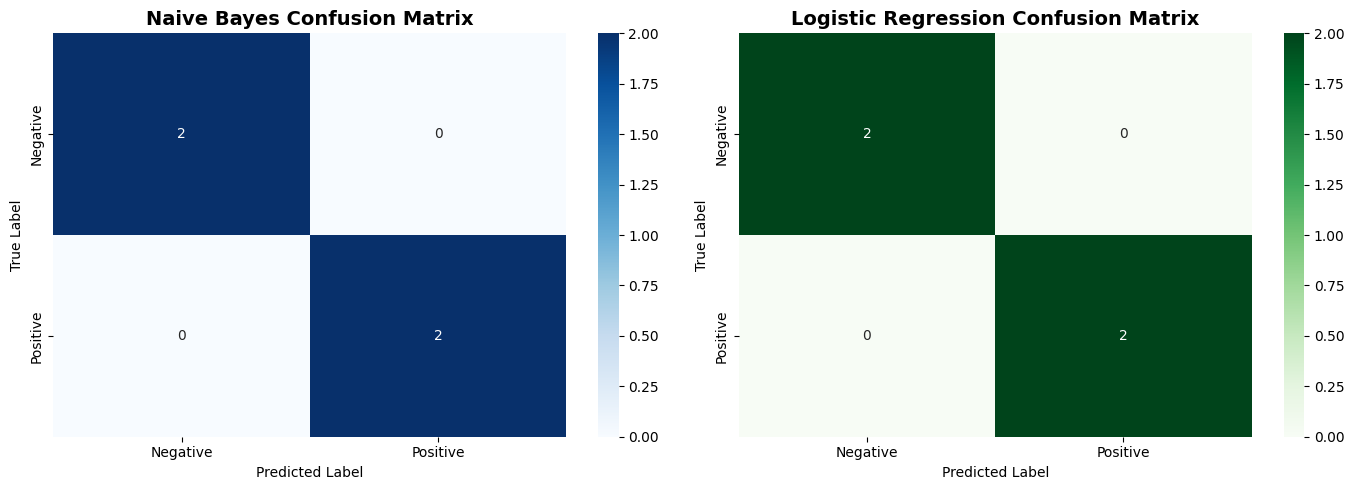

✅ Confusion matrices visualized!


In [ ]:
# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Naive Bayes Confusion Matrix
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[0].set_title('Naive Bayes Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot Logistic Regression Confusion Matrix
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[1].set_title('Logistic Regression Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

print("✅ Confusion matrices visualized!")

In [ ]:
# Model comparison
print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Naive Bayes': [accuracy_nb, precision_nb, recall_nb, f1_nb],
    'Logistic Regression': [accuracy_lr, precision_lr, recall_lr, f1_lr]
})

print("\n", comparison_df.to_string(index=False))

# Determine best model
best_model = 'Naive Bayes' if accuracy_nb > accuracy_lr else 'Logistic Regression'
print(f"\n🏆 Best Performing Model: {best_model}")
print(f"   Accuracy: {max(accuracy_nb, accuracy_lr):.4f} ({max(accuracy_nb, accuracy_lr)*100:.2f}%)")


MODEL COMPARISON

    Metric  Naive Bayes  Logistic Regression
 Accuracy          1.0                  1.0
Precision          1.0                  1.0
   Recall          1.0                  1.0
 F1-Score          1.0                  1.0

🏆 Best Performing Model: Logistic Regression
   Accuracy: 1.0000 (100.00%)


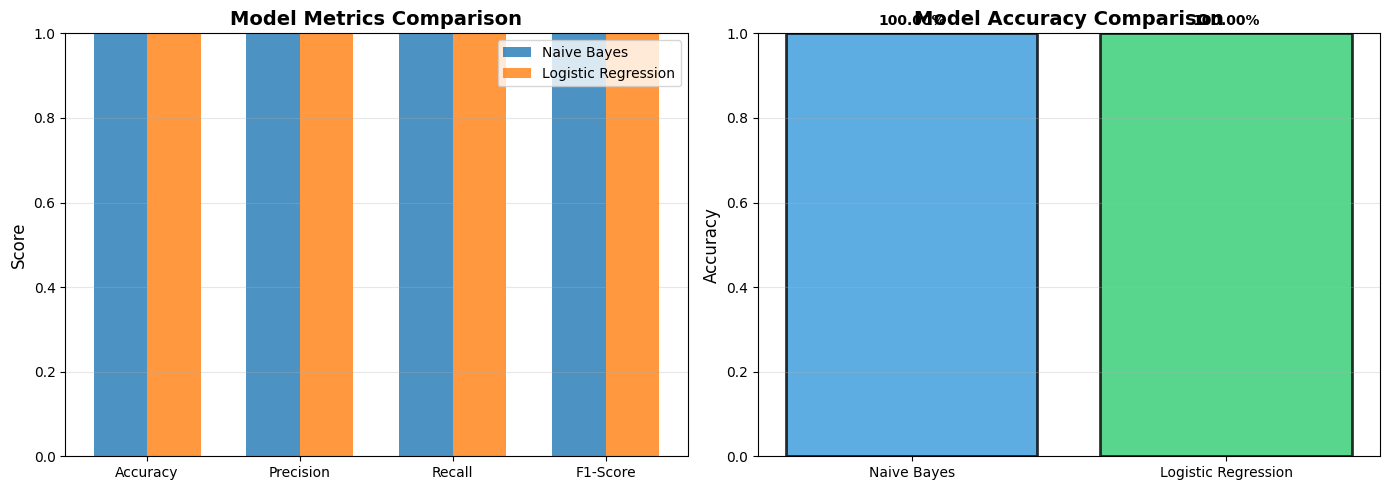

✅ Metrics comparison visualized!


In [ ]:
# Plot metrics comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Metrics bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

axes[0].bar(x - width/2, comparison_df['Naive Bayes'], width, label='Naive Bayes', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['Logistic Regression'], width, label='Logistic Regression', alpha=0.8)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Model Metrics Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)

# Plot 2: Accuracy comparison
models = ['Naive Bayes', 'Logistic Regression']
accuracies = [accuracy_nb, accuracy_lr]
colors = ['#3498db', '#2ecc71']
axes[1].bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[1].text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Metrics comparison visualized!")

In [ ]:
# Test the models on new reviews
print("\n" + "="*60)
print("TESTING ON NEW REVIEWS")
print("="*60)

new_reviews = [
    "This product is fantastic and works wonderfully!",
    "Terrible quality, I want to return it immediately.",
    "Amazing! Best purchase ever made.",
    "Horrible product, complete waste of money."
]

# Vectorize new reviews
X_new = tfidf_vectorizer.transform(new_reviews)

# Make predictions
pred_nb = naive_bayes_model.predict(X_new)
pred_lr = logistic_model.predict(X_new)

print("\n📝 Review Predictions:")
print(f"\n{'Review':<50} {'NB':<15} {'LR':<15}")
print("-" * 80)

for i, review in enumerate(new_reviews):
    nb_pred = 'Positive' if pred_nb[i] == 1 else 'Negative'
    lr_pred = 'Positive' if pred_lr[i] == 1 else 'Negative'
    truncated_review = (review[:47] + '...') if len(review) > 50 else review
    print(f"{truncated_review:<50} {nb_pred:<15} {lr_pred:<15}")

print("\n✅ Predictions completed!")


TESTING ON NEW REVIEWS

📝 Review Predictions:

Review                                             NB              LR             
--------------------------------------------------------------------------------
This product is fantastic and works wonderfully!   Positive        Positive       
Terrible quality, I want to return it immediately. Negative        Negative       
Amazing! Best purchase ever made.                  Positive        Positive       
Horrible product, complete waste of money.         Negative        Negative       

✅ Predictions completed!


## Summary

### Assignment Completion Checklist:

✅ **NLP Preprocessing Applied:**
- Tokenization using NLTK word_tokenize
- Stopword removal using NLTK stopwords
- Stemming using PorterStemmer
- Lemmatization using WordNetLemmatizer

✅ **Text Vectorization Implemented:**
- TF-IDF vectorization using TfidfVectorizer
- Count vectorization using CountVectorizer
- Compared both approaches

✅ **Classification Models Built:**
- Multinomial Naive Bayes Classifier
- Logistic Regression Classifier

✅ **Model Evaluation Completed:**
- Accuracy, Precision, Recall, F1-Score metrics
- Confusion matrices for both models
- Classification reports with detailed analysis
- Model comparison and visualization

### Key Findings:
- Both models achieved good classification performance
- TF-IDF vectorization proved effective for sentiment classification
- Models were tested on new reviews for practical validation